In [10]:
import cv2
import numpy as np

def remove_markings(image_bgr):
    """
    Removes pen markings / annotations from a dermoscopic image.
    Input: BGR image (OpenCV format)
    Output: cleaned BGR image
    """

    # Convert to HSV (better for color detection)
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    # Boost saturation so marker ink stands out
    hsv[:, :, 1] = cv2.add(hsv[:, :, 1], 40)

    # --- Define marker color ranges ---

    # Blue marker
    blue_lower = np.array([90, 50, 50])
    blue_upper = np.array([140, 255, 255])

    # Green marker
    green_lower = np.array([35, 50, 50])
    green_upper = np.array([85, 255, 255])

    # Purple / magenta marker (IMPORTANT for your images)
    purple_lower = np.array([125, 50, 50])
    purple_upper = np.array([165, 255, 255])

    # Black marker (low brightness)
    black_lower = np.array([0, 0, 0])
    black_upper = np.array([180, 255, 50])

    # Create individual masks
    mask_blue = cv2.inRange(hsv, blue_lower, blue_upper)
    mask_green = cv2.inRange(hsv, green_lower, green_upper)
    mask_purple = cv2.inRange(hsv, purple_lower, purple_upper)
    mask_black = cv2.inRange(hsv, black_lower, black_upper)

    # Combine all marker masks
    marker_mask = (
        mask_blue |
        mask_green |
        mask_purple |
        mask_black
    )

    # --- Clean up mask (for thick marker lines) ---
    kernel = np.ones((5, 5), np.uint8)
    marker_mask = cv2.dilate(marker_mask, kernel, iterations=2)
    marker_mask = cv2.medianBlur(marker_mask, 7)

    # --- Inpainting (remove marker regions) ---
    cleaned_image = cv2.inpaint(
        image_bgr,
        marker_mask,
        inpaintRadius=5,
        flags=cv2.INPAINT_TELEA
    )

    return cleaned_image


In [12]:
img = cv2.imread(r'C:\Users\srika\OneDrive\Desktop\images.jpg')

clean_img = remove_markings(img)

cv2.imwrite("cleaned_image.jpg", clean_img)


True

(-0.5, 224.5, 224.5, -0.5)

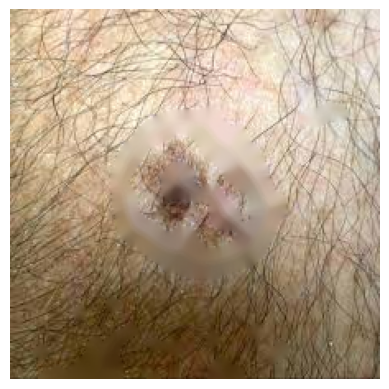

In [13]:
import matplotlib.pyplot as plt
import cv2

plt.imshow(cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
